In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from itertools import product

In [2]:
df = pd.read_csv("tsla_2014_2023.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,open,high,low,close,volume,rsi_7,rsi_14,cci_7,cci_14,sma_50,ema_50,sma_100,ema_100,macd,bollinger,TrueRange,atr_7,atr_14,next_day_close
0,2014-01-02,9.986667,10.165333,9.770000,10.006667,92826000,55.344071,54.440118,-37.373644,15.213422,9.682107,9.820167,10.494240,9.674284,0.169472,9.740800,0.395333,0.402641,0.447550,9.970667
1,2014-01-03,10.000000,10.146000,9.906667,9.970667,70425000,53.742629,53.821521,-81.304471,17.481130,9.652800,9.826069,10.495693,9.680190,0.162623,9.776167,0.239333,0.379311,0.432677,9.800000
2,2014-01-06,10.000000,10.026667,9.682667,9.800000,80416500,46.328174,50.870410,-123.427544,-37.824708,9.629467,9.825047,10.496740,9.682577,0.141790,9.797900,0.344000,0.374267,0.426343,9.957333
3,2014-01-07,9.841333,10.026667,9.683333,9.957333,75511500,53.263037,53.406750,-84.784651,-20.779431,9.597747,9.830235,10.503407,9.688051,0.136402,9.837900,0.343334,0.369848,0.420414,10.085333
4,2014-01-08,9.923333,10.246667,9.917333,10.085333,92448000,58.368660,55.423026,60.799662,43.570559,9.573240,9.840239,10.511147,9.695964,0.140837,9.870167,0.329334,0.364060,0.413908,9.835333


In [3]:
# ── Use log-transformed close price for better stationarity & accuracy ──
data = np.log(df['close'])

train_size = int(len(data) * 0.8)
train = data[:train_size]
test  = data[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 2012, Test size: 504


In [4]:
# ── ADF test to confirm stationarity after differencing ──
result = adfuller(train.diff().dropna())
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print("Series is stationary" if result[1] < 0.05 else "Series is NOT stationary")

ADF Statistic : -21.9877
p-value       : 0.0000
Series is stationary


In [5]:
from statsmodels.tsa.arima.model import ARIMA
from itertools import product
import numpy as np
import warnings

warnings.filterwarnings("ignore")  # suppress warnings

best_aic = np.inf
best_order = None

for p, d, q in product(range(5), range(1, 3), range(5)):
    try:
        model = ARIMA(train, order=(p, d, q))
        model_fit = model.fit(method_kwargs={"maxiter": 200})
        
        aic = model_fit.aic
        
        if aic < best_aic:
            best_aic = aic
            best_order = (p, d, q)

    except:
        continue

print(f"Best ARIMA order: {best_order} (AIC = {best_aic:.2f})")

Best ARIMA order: (0, 1, 3) (AIC = -7875.98)


In [6]:
# ── Fit the best model ──
model_fit = ARIMA(train, order=best_order).fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                 2012
Model:                 ARIMA(0, 1, 3)   Log Likelihood                3941.992
Date:                Sun, 12 Apr 2026   AIC                          -7875.984
Time:                        22:59:21   BIC                          -7853.559
Sample:                             0   HQIC                         -7867.752
                               - 2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0032      0.016      0.201      0.841      -0.028       0.035
ma.L2          0.0457      0.015      2.965      0.003       0.016       0.076
ma.L3          0.0421      0.016      2.717      0.0

In [7]:
# ── Rolling / walk-forward forecast (much more realistic & accurate) ──
# Instead of forecasting all test steps at once, we retrain on every new
# observation so the model always sees the latest data.

history     = list(train)
predictions_log = []

for t in range(len(test)):
    fit  = ARIMA(history, order=best_order).fit()
    yhat = fit.forecast(steps=1)[0]
    predictions_log.append(yhat)
    history.append(test.iloc[t])   # add the true value for the next step

# Convert back from log-space to original price space
predictions_log = np.array(predictions_log)
predictions = np.exp(predictions_log)
actual      = np.exp(test.values)

print("Rolling forecast complete.")

Rolling forecast complete.


In [8]:
# ── Evaluation ──
rmse     = np.sqrt(mean_squared_error(actual, predictions))
mae      = np.mean(np.abs(actual - predictions))
mape     = np.mean(np.abs((actual - predictions) / actual)) * 100
accuracy = 100 - mape          # accuracy based on MAPE (more reliable than RMSE-based)

print(f"RMSE            : {rmse:.4f}")
print(f"MAE             : {mae:.4f}")
print(f"MAPE            : {mape:.2f}%")
print(f"Approx Accuracy : {accuracy:.2f}%")



RMSE            : 9.3839
MAE             : 6.8651
MAPE            : 2.89%
Approx Accuracy : 97.11%


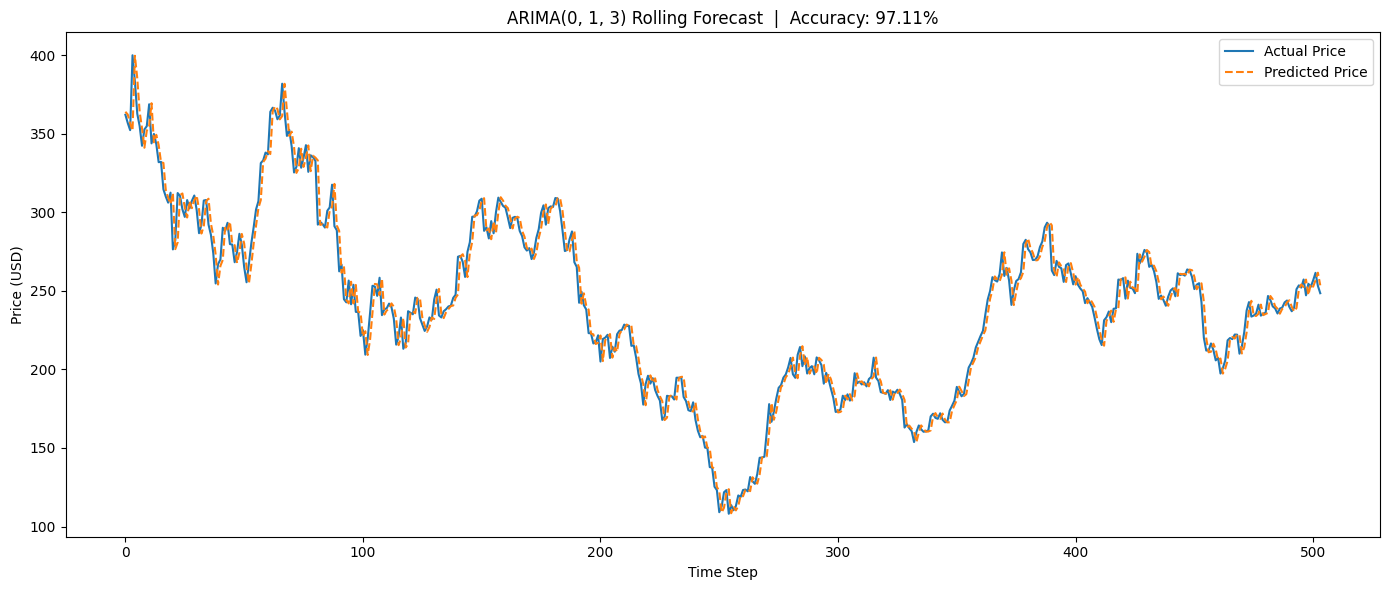

In [9]:
# ── Plot ──
plt.figure(figsize=(14, 6))
plt.plot(actual,      label='Actual Price',    linewidth=1.5)
plt.plot(predictions, label='Predicted Price', linewidth=1.5, linestyle='--')
plt.title(f'ARIMA{best_order} Rolling Forecast  |  Accuracy: {accuracy:.2f}%')
plt.xlabel('Time Step')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()